<a href="https://colab.research.google.com/github/vishalakshi-19/ML_Week1/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
np.random.seed(23)


In [2]:
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)


In [3]:
df =  pd.DataFrame(class1_sample,columns=['feature1','feature2','feature3'])
df['target']=1

In [4]:
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,1],[0,0,1]])
class2_sample =  np.random.multivariate_normal(mu_vec2,cov_mat2,20)
df1 = pd.DataFrame(class2_sample,columns=['feature1','feature2','feature3'])

/tmp/ipykernel_531/3884056301.py:3: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  class2_sample =  np.random.multivariate_normal(mu_vec2,cov_mat2,20)


In [5]:
df1['target']=0
df = pd.concat([df, df1], ignore_index=True)
df = df.sample(40)
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,-0.598109,0.298190,0.203162,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [6]:
import plotly.express as px
fig = px.scatter_3d(df,x=df['feature1'],y=df['feature2'],z=df['feature3'],color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))
fig.show()

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [8]:
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n',covariance_matrix)

Covariance Matrix:
 [[ 1.02564103  0.31788754 -0.00148418]
 [ 0.31788754  1.02564103  0.43311833]
 [-0.00148418  0.43311833  1.02564103]]


In [9]:
eigen_values,eigen_vectors = np.linalg.eig(covariance_matrix)
eigen_values

array([0.48767645, 1.02705693, 1.5621897 ])

In [11]:
eigen_vectors

array([[ 0.41913226, -0.80616857,  0.41763667],
       [-0.7066405 , -0.00082825,  0.70757227],
       [ 0.57007662,  0.59168534,  0.57001851]])

In [13]:
%pylab inline
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch

Populating the interactive namespace from numpy and matplotlib


In [15]:
class Arrow3D(FancyArrowPatch):
  def __init__(self,xs,ys,zs,*args,**kwargs):
    FancyArrowPatch.__init__(self,(0,0),(0,0),*args,**kwargs)
    self.__verts3d =  xs, ys, zs
  def draw(self,renderer):
    xs3d,ys3d,zs3d = self.__verts3d
    xs,ys,zs = proj3d.proj_transform(xs3d,ys3d,zs3d,renderer.M)
    self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
    FancyArrowPatch.draw(self,renderer)

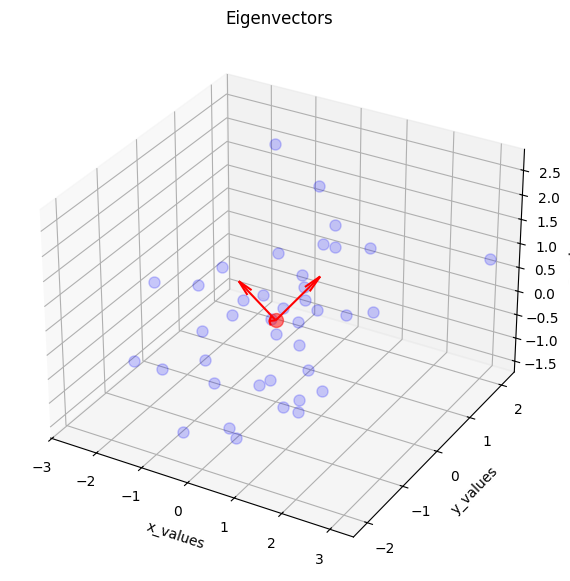

In [18]:
fig = plt.figure(figsize = (7,7))
ax = fig.add_subplot(111,projection='3d')
ax.plot(df['feature1'],df['feature2'],df['feature3'],'o',markersize=8,color='blue',alpha=0.2)

mean_x, mean_y, mean_z = df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()
ax.plot([mean_x],[mean_y],[mean_z],'o',markersize=10,color='red',alpha=0.5)

# Plot eigenvectors using Matplotlib's built-in quiver function
for v in eigen_vectors.T:
    ax.quiver(mean_x, mean_y, mean_z, v[0], v[1], v[2], color='r', length=1.0, normalize=True)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors')
plt.show()

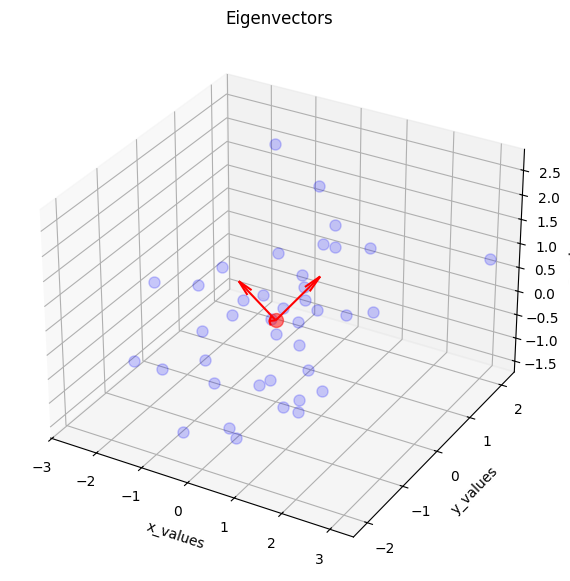

In [19]:
fig = plt.figure(figsize = (7,7))
ax = fig.add_subplot(111,projection='3d')
ax.plot(df['feature1'],df['feature2'],df['feature3'],'o',markersize=8,color='blue',alpha=0.2)

mean_x, mean_y, mean_z = df['feature1'].mean(), df['feature2'].mean(), df['feature3'].mean()
ax.plot([mean_x],[mean_y],[mean_z],'o',markersize=10,color='red',alpha=0.5)

# Plot eigenvectors using Matplotlib's built-in quiver function
for v in eigen_vectors.T:
    ax.quiver(mean_x, mean_y, mean_z, v[0], v[1], v[2], color='r', length=1.0, normalize=True)

ax.set_xlabel('x_values')
ax.set_ylabel('y_values')
ax.set_zlabel('z_values')
plt.title('Eigenvectors')
plt.show()

In [20]:
pc = eigen_vectors[0:2]
pc

array([[ 0.41913226, -0.80616857,  0.41763667],
       [-0.7066405 , -0.00082825,  0.70757227]])

In [21]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.259946,-0.520581,1
1,-0.535122,0.563827,0
2,-0.373967,-0.217625,1
3,0.803813,-1.522570,1
4,-0.931961,1.958454,1


In [23]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10)
fig.update_traces(marker=dict(size=12,line=dict(width=2,color='DarkSlateGrey')),selector=dict(mode='markers'))
fig.show()